# Lesson 4: Hypothesis Testing - Practical Lab

This comprehensive lab applies all major hypothesis testing concepts to real-world scenarios.

**Instructions:** Complete all 4 scenarios below. Use the solution notebook (`08-practical-lab-solution.ipynb`) as a reference if needed.

## Setup
Import required libraries and set up the environment.

In [1]:
# TODO: Import required libraries
# Hint: You'll need numpy, pandas, matplotlib.pyplot, seaborn, scipy.stats
# Also import: proportions_ztest from statsmodels.stats.proportion
#              ttest_ind from statsmodels.stats.weightstats

# Your imports here:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.weightstats import ttest_ind

# Set up visualization theme (optional but recommended)
sns.set_theme(context="talk", style="whitegrid")
# Example palette (can be customized)
sns.set_palette("colorblind")

# Create random number generator with seed for reproducibility
rng = np.random.default_rng(2025)

## Scenario 1: Drug Trial Analysis

**Context:** Testing new drug (Drug A) vs. standard treatment (Drug B)  
**Question:** Does Drug A reduce recovery time?  
**H₀:** μ_A = μ_B  
**H₁:** μ_A < μ_B  
**α = 0.05** (one-tailed)

### Task 1.1: Generate Data
- Generate 50 samples for Drug A: normal(loc=28, scale=8)
- Generate 50 samples for Drug B: normal(loc=42, scale=10)
- Create a DataFrame with columns: patient_id, treatment, recovery_time_hours

In [2]:
# TODO: Generate drug trial data
# Hint: Use rng.normal() to generate samples from normal distribution
# Drug A: loc=28, scale=8, size=50
# Drug B: loc=42, scale=10, size=50

n_a, n_b = 50, 50

# Generate recovery times
recovery_a = rng.normal(loc=28, scale=8, size=n_a)
recovery_b = rng.normal(loc=42, scale=10, size=n_b)
      

# Create DataFrame with columns: patient_id, treatment, recovery_time_hours
data = {
          'patient_id': np.arange(n_a + n_b),
          'treatment': ['Drug A'] * n_a + ['Drug B'] * n_b,
          'recovery_time_hours': np.concatenate([recovery_a, recovery_b])
      }
df = pd.DataFrame(data)

# Display summary statistics grouped by treatment
print(df.groupby('treatment')['recovery_time_hours'].describe())

           count       mean        std        min        25%        50%  \
treatment                                                                 
Drug A      50.0  26.846604   9.144164   8.155007  21.327725  28.647067   
Drug B      50.0  42.721223  11.575778  13.024040  36.627523  43.039423   

                 75%        max  
treatment                        
Drug A     32.880377  51.488086  
Drug B     51.922835  63.745761  


### Task 1.2: Exploratory Analysis
- Create 3 subplots: box plot, histograms, violin plot
- Visualize recovery time distributions for both treatments

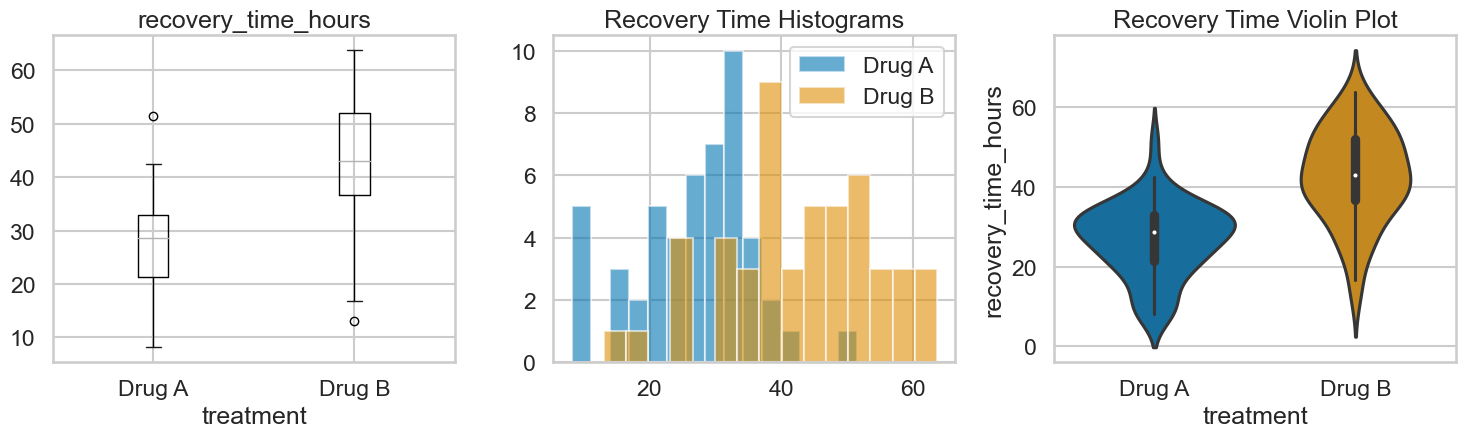

In [3]:
# TODO: Create visualizations
# Hint: Create 3 subplots in one row using plt.subplots(1, 3, figsize=(15, 5))
# Plot 1: Box plot - use drug_trial_df.boxplot(column=..., by=..., ax=axes[0])
# Plot 2: Overlapping histograms - use axes[1].hist() in a loop for each treatment
# Plot 3: Violin plot - use sns.violinplot(data=..., x=..., y=..., ax=axes[2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Subplot 1: Box plot
# TODO: Create box plot showing recovery_time_hours by treatment
df.boxplot(column='recovery_time_hours', by='treatment', ax=axes[0])
fig.suptitle('') # Suppress the default pandas boxplot suptitle

# Subplot 2: Histograms
# TODO: Loop through treatments and create overlapping histograms
# Use bins=15, alpha=0.6 for transparency, add labels and legend
for treatment in df['treatment'].unique():
          axes[1].hist(df[df['treatment'] == treatment]['recovery_time_hours'],
                       bins=15, alpha=0.6, label=treatment)
axes[1].legend()
axes[1].set_title('Recovery Time Histograms')

# Subplot 3: Violin plot
# TODO: Create violin plot with treatment on x-axis, recovery_time_hours on y-axis
sns.violinplot(data=df, x='treatment', y='recovery_time_hours', ax=axes[2])
axes[2].set_title('Recovery Time Violin Plot')

plt.tight_layout()
plt.show()

### Task 1.3: Check Assumptions
- Create Q-Q plots for both groups
- Perform Shapiro-Wilk normality tests
- Perform Levene's test for equal variances

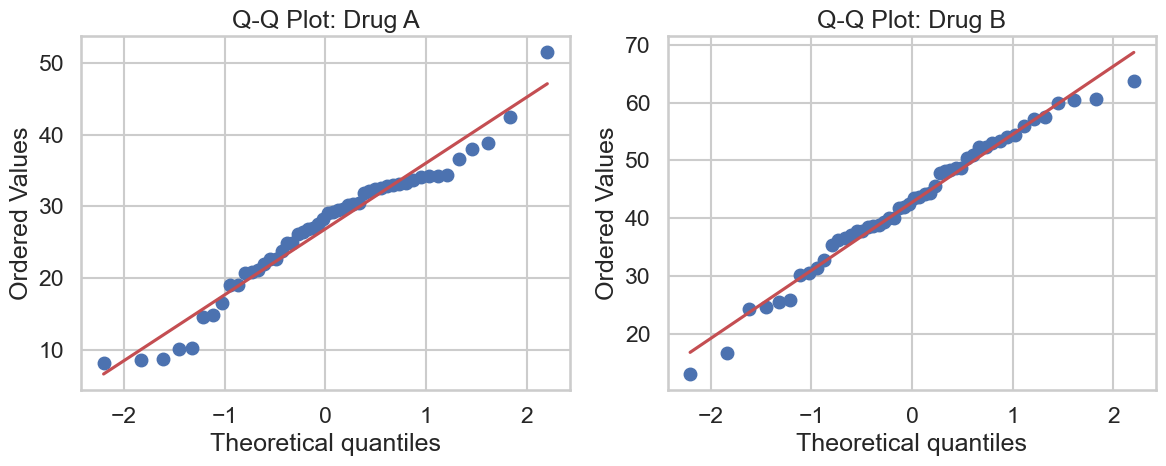

\n🔍 Normality Tests (Shapiro-Wilk):
  Drug A: Statistic=0.9613201022148132, p-value=0.10097172856330872
  Drug B: Statistic=0.9792385697364807, p-value=0.5203118920326233
\n🔍 Equal Variance Test (Levene's):
  Statistic=2.848341398273898, p-value=0.09464853860387207


In [4]:
# TODO: Check normality and equal variance assumptions
# Hint: Use stats.probplot(data, dist="norm", plot=ax) for Q-Q plots
#       Use stats.shapiro(data) for normality test - returns (statistic, p_value)
#       Use stats.levene(data1, data2) for equal variance test

# Create Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TODO: Loop through treatments and create Q-Q plots
# For each treatment: extract data, use stats.probplot(), set title and grid
treatments = df['treatment'].unique()
stats.probplot(df[df['treatment'] == treatments[0]]['recovery_time_hours'], dist="norm", plot=axes[0])
axes[0].set_title(f'Q-Q Plot: {treatments[0]}')
axes[0].grid(True)
      
stats.probplot(df[df['treatment'] == treatments[1]]['recovery_time_hours'], dist="norm", plot=axes[1])
axes[1].set_title(f'Q-Q Plot: {treatments[1]}')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality tests
print("\\n🔍 Normality Tests (Shapiro-Wilk):")
# TODO: Loop through treatments, perform stats.shapiro(), print W and p-value
for treatment in treatments:
    data = df[df['treatment'] == treatment]['recovery_time_hours']
    stat, p_value = stats.shapiro(data)
    print(f"  {treatment}: Statistic={stat}, p-value={p_value}")

# Levene's test for equal variances
# TODO: Extract data for both treatments separately
drug_a_data = df[df['treatment'] == treatments[0]]['recovery_time_hours']
drug_b_data = df[df['treatment'] == treatments[1]]['recovery_time_hours']
# TODO: Perform stats.levene(drug_a_data, drug_b_data)
levene_stat, levene_p = stats.levene(drug_a_data, drug_b_data)

print(f"\\n🔍 Equal Variance Test (Levene's):")
# TODO: Print Levene's statistic and p-value
print(f"  Statistic={levene_stat}, p-value={levene_p}")

### Task 1.4: Perform Welch's t-Test
- Use `ttest_ind` with alternative='smaller' and usevar='unequal'
- Report t-statistic, p-value, and degrees of freedom
- Make a decision at α = 0.05

In [5]:
# TODO: Perform Welch's t-test
# Hint: Use ttest_ind(data1, data2, alternative='smaller', usevar='unequal')
#       alternative='smaller' tests if Drug A < Drug B (one-tailed)
#       usevar='unequal' performs Welch's t-test (doesn't assume equal variances)

# TODO: Perform the test
t_stat, p_value, df_welch = ttest_ind(drug_a_data, drug_b_data, 
                                            alternative='smaller', usevar='unequal')


print("\\n📊 Welch's t-Test Results:")
# TODO: Print t-statistic, p-value, and degrees of freedom
print(f"  t-Statistic: {t_stat}")
print(f"  p-Value: {p_value}")
print(f"  Degrees of Freedom: {df_welch}")

# Decision at α = 0.05
# TODO: Make decision based on p-value
alpha = 0.05
if p_value < alpha:
          print(f"\nDecision: Reject H_0. Drug A has a significantly smaller recovery time (p < {alpha}).")
else:
          print(f"\nDecision: Fail to reject H_0. No significant difference found (p >= {alpha}).")

\n📊 Welch's t-Test Results:
  t-Statistic: -7.609296933961743
  p-Value: 1.0998694939144148e-11
  Degrees of Freedom: 93.01413939593516

Decision: Reject H_0. Drug A has a significantly smaller recovery time (p < 0.05).


### Task 1.5: Calculate Effect Size
- Compute Cohen's d
- Interpret the effect size (small/medium/large)

In [6]:
# TODO: Calculate Cohen's d
# Hint: Cohen's d = (mean_A - mean_B) / pooled_std
#       pooled_std = sqrt(((n_a-1)*std_a^2 + (n_b-1)*std_b^2) / (n_a+n_b-2))
#       Interpretation: |d| >= 0.8 (large), >= 0.5 (medium), < 0.5 (small)

# TODO: Calculate means and standard deviations
# Assumes drug_a_data and drug_b_data from cell 1.3
mean_a = drug_a_data.mean()
mean_b = drug_b_data.mean()
std_a = drug_a_data.std(ddof=1) # Use ddof=1 for sample std dev
std_b = drug_b_data.std(ddof=1)
# TODO: Calculate pooled standard deviation
pooled_std = np.sqrt(((n_a - 1) * std_a**2 + (n_b - 1) * std_b**2) / (n_a + n_b - 2))

# TODO: Calculate Cohen's d
cohen_d = (mean_a - mean_b) / pooled_std

# TODO: Print and interpret effect size
print(f"Cohen's d: {cohen_d}")
      
d_abs = np.abs(cohen_d)

if d_abs >= 0.8:
    interpretation = "large"
elif d_abs >= 0.5:
    interpretation = "medium"
else:
    interpretation = "small"
          
print(f"Interpretation: {interpretation} effect size")

Cohen's d: -1.5218593867923478
Interpretation: large effect size


### Task 1.6: Confidence Interval
- Calculate 95% CI for the difference in means
- Interpret the interval

In [7]:
# TODO: Calculate 95% confidence interval
# Hint: CI = diff_mean ± t_critical * SE_diff
#       SE_diff = sqrt(std_a^2/n_a + std_b^2/n_b)
#       t_critical from t-distribution with df degrees of freedom at 97.5% (two-tailed)

# TODO: Calculate difference in means
diff_mean = mean_a - mean_b
print("diff_mean:",diff_mean)
# TODO: Calculate standard error of the difference
str_error= np.sqrt(std_a**2 / n_a + std_b**2 / n_b)
print("str_error:",str_error)
# TODO: Get critical t-value
alph = 0.05
t_value = stats.t.ppf(1 - alpha / 2, df=df_welch)
print("t_value:",t_value)
# TODO: Calculate confidence interval bounds
lower_b = diff_mean - t_value * str_error
upper_b = diff_mean + t_value * str_error
# TODO: Print confidence interval
print("lower_b:",lower_b)
print("upper_b:",upper_b)
print("confidence interval:",upper_b - lower_b )

diff_mean: -15.87461981234259
str_error: 2.0862137396020306
t_value: 1.9857978359673165
lower_b: -20.017418541809587
upper_b: -11.731821082875594
confidence interval: 8.285597458933992


### Task 1.7: Comprehensive Report
- Summarize findings
- Include test statistic, p-value, effect size, and CI
- Provide recommendation

In [8]:
# TODO: Print comprehensive report
# Hint: Include all key findings in a professional format

print("\n" + "="*70)
print("SCENARIO 1: DRUG TRIAL - COMPREHENSIVE REPORT")
print("="*70)
# TODO: Print results summary with all statistics

print(f"1. Hypothesis:")
print(f"   - H_0: Mean recovery time for Drug A is equal to Drug B (μ_A = μ_B).")
print(f"   - H_1: Mean recovery time for Drug A is less than Drug B (μ_A < μ_B).")
print(f"   - Alpha (α): {alpha}")
      
print(f"\n2. Key Statistics:")
print(f"   - Difference in Means (A - B): {diff_mean:}")
print(f"   - Welch's t-Statistic: {t_stat}")
print(f"   - Degrees of Freedom (Welch): {df_welch}") 
print(f"   - p-Value (one-tailed): {p_value}")
      
print(f"\n3. Effect Size:")
print(f"   - Cohen's d: {cohen_d}")
print(f"   - Interpretation: {interpretation} effect size")

print(f"\n4. Confidence Interval:")
print("confidence interval:",upper_b - lower_b )
      
print(f"\n5. Conclusion & Recommendation:")
if p_value < alpha:
    print(f"   - Conclusion: The p-value ({p_value}) is less than alpha ({alpha}), so we reject H_0.")
    print(f"   - Recommendation: The results suggest Drug A significantly reduces recovery time compared to Drug B.")
else:
    print(f"   - Conclusion: The p-value ({p_value}) is greater than alpha ({alpha}), so we fail to reject H_0.")
    print(f"   - Recommendation: There is not enough statistical evidence to conclude that Drug A reduces recovery time compared to Drug B.")
      
# Include: difference in means, t-statistic, p-value, Cohen's d, CI
print("="*70)


SCENARIO 1: DRUG TRIAL - COMPREHENSIVE REPORT
1. Hypothesis:
   - H_0: Mean recovery time for Drug A is equal to Drug B (μ_A = μ_B).
   - H_1: Mean recovery time for Drug A is less than Drug B (μ_A < μ_B).
   - Alpha (α): 0.05

2. Key Statistics:
   - Difference in Means (A - B): -15.87461981234259
   - Welch's t-Statistic: -7.609296933961743
   - Degrees of Freedom (Welch): 93.01413939593516
   - p-Value (one-tailed): 1.0998694939144148e-11

3. Effect Size:
   - Cohen's d: -1.5218593867923478
   - Interpretation: large effect size

4. Confidence Interval:
confidence interval: 8.285597458933992

5. Conclusion & Recommendation:
   - Conclusion: The p-value (1.0998694939144148e-11) is less than alpha (0.05), so we reject H_0.
   - Recommendation: The results suggest Drug A significantly reduces recovery time compared to Drug B.


## Scenario 2: A/B Test Analysis

**Context:** Testing two website designs  
**Question:** Does Variant B have higher conversion rate?  
**H₀:** p_B = p_A  
**H₁:** p_B > p_A  
**α = 0.05**

### Task 2.1: Generate A/B Test Data
- Variant A: 1000 visitors, conversion rate 9%
- Variant B: 1000 visitors, conversion rate 12%
- Use binomial distribution to generate conversions

In [20]:
# TODO: Generate A/B test data
# Hint: Use rng.binomial(n=1, p=conversion_rate, size=n_visitors).sum()
#       Variant A: 1000 visitors, 9% conversion (p=0.09)
#       Variant B: 1000 visitors, 12% conversion (p=0.12)

n_visitors_a, n_visitors_b = 1000, 1000

# TODO: Generate conversions using binomial distribution
conversions_a = rng.binomial(n=1, p=0.09, size=n_visitors_a).sum()
conversions_b = rng.binomial(n=1, p=0.12, size=n_visitors_b).sum()

# TODO: Calculate conversion rates (p_hat)
p_hat_a = conversions_a / n_visitors_a
p_hat_b = conversions_b / n_visitors_b

# TODO: Print conversion rates
print(f"Variant A: {conversions_a} conversions from {n_visitors_a} visitors (Rate: {p_hat_a:.2%})")
print(f"Variant B: {conversions_b} conversions from {n_visitors_b} visitors (Rate: {p_hat_b:.2%})")

Variant A: 85 conversions from 1000 visitors (Rate: 8.50%)
Variant B: 131 conversions from 1000 visitors (Rate: 13.10%)


### Task 2.2: Visualize Conversion Rates
- Create bar plot with error bars (95% CIs)
- Annotate with conversion percentages

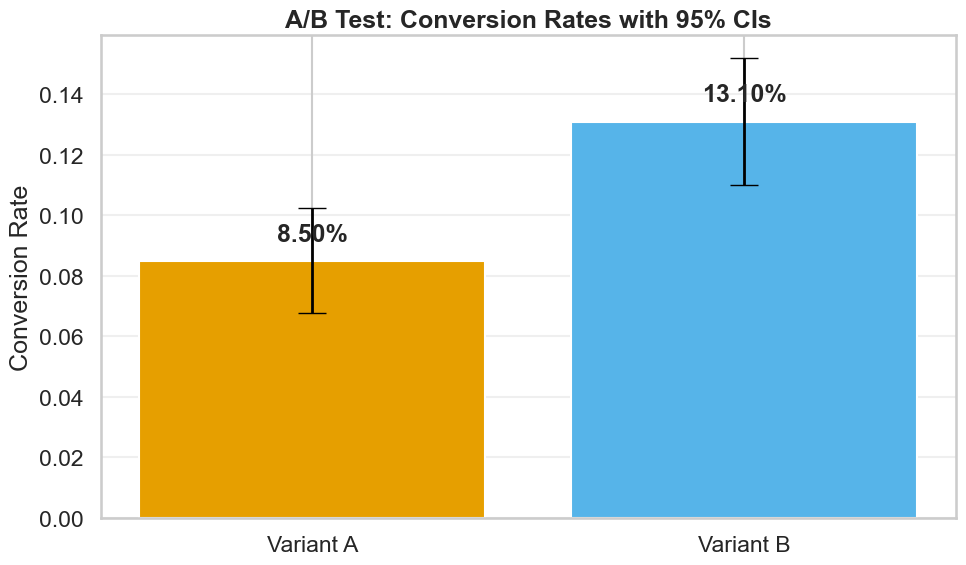

In [24]:
# TODO: Visualize conversion rates with confidence intervals
# Hint: Use ax.bar(x, height, ...) for bars
#       Use ax.errorbar(x, y, yerr=..., fmt='none', ...) for error bars
#       Use ax.text() to add percentage labels on top of bars
#       SE = sqrt(p_hat * (1 - p_hat) / n), Error bars = 1.96 * SE (for 95% CI)

# TODO: Calculate standard errors for both variants (se_a, se_b)
se_a = np.sqrt(p_hat_a * (1 - p_hat_a) / n_visitors_a)
se_b = np.sqrt(p_hat_b * (1 - p_hat_b) / n_visitors_b)

# Create bar plot with error bars
fig, ax = plt.subplots(figsize=(10, 6))

# TODO: Create lists for variants, rates, and errors
variants = ['Variant A', 'Variant B']
rates = [p_hat_a, p_hat_b]
error_bars = [1.96 * se_a, 1.96 * se_b]

# TODO: Use ax.bar() to create bars with colors ['#E69F00', '#56B4E9']
bars = ax.bar(variants, rates, color=['#E69F00', '#56B4E9'])


# TODO: Use ax.errorbar() to add error bars (capsize=10, linewidth=2)
ax.errorbar(variants, rates, yerr=error_bars, fmt='none', capsize=10, 
                  linewidth=2, ecolor='black')

# TODO: Loop through bars and rates, use ax.text() to add percentage labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.005, # Position slightly above bar
            f'{height:.2%}', ha='center', va='bottom', fontweight='bold')

# TODO: Set ylabel, title, and grid
ax.set_ylabel('Conversion Rate')
ax.set_title('A/B Test: Conversion Rates with 95% CIs', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Task 2.3: Two-Proportion z-Test
- Use `proportions_ztest` with alternative='larger'
- Report z-statistic and p-value
- Make a decision

In [28]:
# TODO: Perform two-proportion z-test
# Hint: Use proportions_ztest(count, nobs, alternative='larger')
#       count = array of successes [conversions_a, conversions_b]
#       nobs = array of sample sizes [n_visitors_a, n_visitors_b]
#       alternative='larger' tests if p_b > p_a

# TODO: Create count and nobs arrays
# We are testing H1: p_B > p_A, so B is group 1, A is group 2.
count = np.array([conversions_b, conversions_a])
nobs = np.array([n_visitors_b, n_visitors_a])

# TODO: Perform the test
z_stat, p_value = proportions_ztest(count=count, nobs=nobs, alternative='larger')

# TODO: Print results and make decision
print(f"Two-Proportion z-Test Results (H1: p_B > p_A):")
print(f"  z-Statistic: {z_stat:}")
print(f"  p-Value: {p_value:}")
      
alpha = 0.05
if p_value < alpha:
    print(f"\nDecision: Reject H_0. Variant B has a significantly higher conversion rate (p < {alpha}).")
else:
     print(f"\nDecision: Fail to reject H_0. No significant evidence that Variant B is better (p >= {alpha}).")

Two-Proportion z-Test Results (H1: p_B > p_A):
  z-Statistic: 3.313969666578862
  p-Value: 0.0004599074260917152

Decision: Reject H_0. Variant B has a significantly higher conversion rate (p < 0.05).


### Task 2.4: Business Impact Analysis
- Calculate absolute lift (percentage point difference)
- Calculate relative lift (% improvement)
- Estimate annual revenue impact (assume 100k monthly visitors, $50 avg order)

In [29]:
# TODO: Calculate business impact
# Hint: Absolute lift = p_b_hat - p_a_hat (percentage point difference)
#       Relative lift = (p_b_hat - p_a_hat) / p_a_hat * 100 (% improvement)
#       Assume: 100,000 monthly visitors, $50 average order value

# TODO: Calculate absolute lift
# Assumes p_hat_a and p_hat_b from cell 2.1
absolute_lift = p_hat_b - p_hat_a

# TODO: Calculate relative lift
relative_lift = (p_hat_b - p_hat_a) / p_hat_a * 100

# TODO: Calculate revenue impact
monthly_visitors = 100000
avg_order_value = 50
additional_conversions = monthly_visitors * absolute_lift
additional_revenue = additional_conversions * avg_order_value


# TODO: Print business impact summary
print("\nBusiness Impact Analysis:")
print(f"  Absolute Lift (Percentage Point Difference): {absolute_lift:+.2%}")
print(f"  Relative Lift (% Improvement): {relative_lift:+.2f}%")
print(f"\nEstimated Annual Revenue Impact:")
print(f"  Estimated Additional Monthly Conversions: {additional_conversions:.0f}")
print(f"  Estimated Additional Monthly Revenue: ${additional_revenue:,.2f}")
print(f"  Estimated Additional Annual Revenue: ${additional_revenue * 12:,.2f}")


Business Impact Analysis:
  Absolute Lift (Percentage Point Difference): +4.60%
  Relative Lift (% Improvement): +54.12%

Estimated Annual Revenue Impact:
  Estimated Additional Monthly Conversions: 4600
  Estimated Additional Monthly Revenue: $230,000.00
  Estimated Additional Annual Revenue: $2,760,000.00


## Scenario 3: Survey Analysis (Chi-Squared)

**Context:** Product preference by age group  
**Question:** Is preference independent of age?  
**H₀:** Independence  
**H₁:** Association

### Task 3.1: Create Contingency Table
- Young: [45, 30, 25] for Products A, B, C
- Middle: [30, 40, 30]
- Old: [25, 30, 45]
- Create DataFrame with proper labels

In [30]:
# TODO: Create contingency table
# Hint: Use np.array() to create a 3x3 matrix
#       Rows: age groups (Young, Middle, Old)
#       Columns: products (A, B, C)
#       Data: Young: [45, 30, 25], Middle: [30, 40, 30], Old: [25, 30, 45]

# TODO: Create contingency table array
contingency_data = np.array([[45, 30, 25], 
                             [30, 40, 30], 
                             [25, 30, 45]])

# Define labels
age_groups = ['Young', 'Middle', 'Old']
products = ['Product A', 'Product B', 'Product C']

# TODO: Create DataFrame for better display
contingency_df = pd.DataFrame(contingency_data, index=age_groups, columns=products)

# TODO: Print the table
print(contingency_df)

        Product A  Product B  Product C
Young          45         30         25
Middle         30         40         30
Old            25         30         45


### Task 3.2: Visualize
- Create 2 heatmaps: observed frequencies and proportions within age groups
- Use appropriate color maps

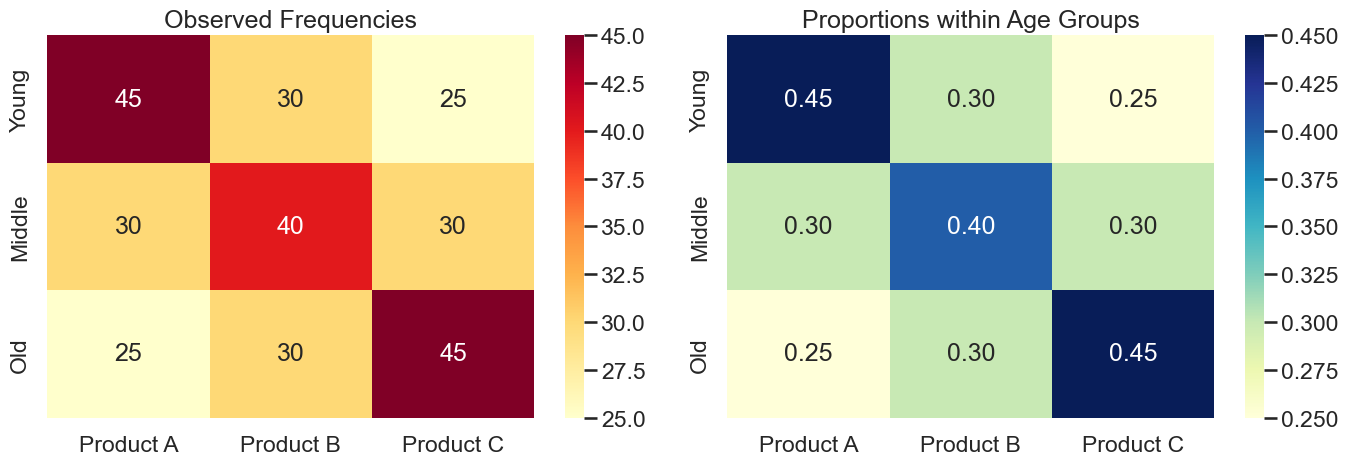

In [31]:
# TODO: Create heatmaps
# Hint: Use sns.heatmap(data, annot=True, fmt=..., cmap=..., xticklabels=..., yticklabels=..., ax=...)
#       fmt='d' for integers (observed frequencies)
#       fmt='.2f' for floats (proportions)
#       Good colormaps: 'YlOrRd' for frequencies, 'YlGnBu' for proportions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap 1: Observed frequencies
# TODO: Use sns.heatmap() with contingency_table, annot=True, fmt='d', cmap='YlOrRd'
# Set xticklabels=products, yticklabels=age_groups, ax=axes[0]
# Set title 'Observed Frequencies'
# Assumes contingency_df, products, and age_groups from cell 3.1
sns.heatmap(contingency_df, annot=True, fmt='d', cmap='YlOrRd',xticklabels=products, yticklabels=age_groups, ax=axes[0])
axes[0].set_title('Observed Frequencies')

# Heatmap 2: Proportions within age groups
# TODO: Calculate proportions by dividing each row by its sum
# Hint: proportions = contingency_table / contingency_table.sum(axis=1, keepdims=True)
# Assumes contingency_data from cell 3.1
proportions = contingency_data / contingency_data.sum(axis=1, keepdims=True)

# TODO: Use sns.heatmap() with proportions, annot=True, fmt='.2f', cmap='YlGnBu'
# Set xticklabels=products, yticklabels=age_groups, ax=axes[1]
# Set title 'Proportions within Age Groups'
sns.heatmap(proportions, annot=True, fmt='.2f', cmap='YlGnBu', xticklabels=products, yticklabels=age_groups, ax=axes[1])
axes[1].set_title('Proportions within Age Groups')

plt.tight_layout()
plt.show()

### Task 3.3: Chi-Squared Test
- Use `stats.chi2_contingency`
- Report χ², degrees of freedom, and p-value
- Make a decision

In [32]:
# TODO: Perform chi-squared test
# Hint: Use stats.chi2_contingency(contingency_table)
#       Returns: chi2_stat, p_value, dof, expected_frequencies

# TODO: Perform chi-squared test
# Assumes contingency_data from cell 3.1
chi2_stat, p_value, dof, expected_frequencies = stats.chi2_contingency(contingency_data)

# TODO: Print results
print("\nChi-Squared Test Results:")
print(f"  Chi-squared Statistic (χ²): {chi2_stat:.4f}")
print(f"  p-Value: {p_value:.4f}")
print(f"  Degrees of Freedom (dof): {dof}")

# TODO: Make decision at α = 0.05
alpha = 0.05
if p_value < alpha:
    print(f"\nDecision: Reject H_0. There is a significant association between age group and product preference (p < {alpha}).")
else:
    print(f"\nDecision: Fail to reject H_0. Product preference is independent of age group (p >= {alpha}).")


Chi-Squared Test Results:
  Chi-squared Statistic (χ²): 15.0000
  p-Value: 0.0047
  Degrees of Freedom (dof): 4

Decision: Reject H_0. There is a significant association between age group and product preference (p < 0.05).


## Scenario 4: Non-Normal Data (Nonparametric)

**Context:** Comparing salaries with outliers  
**Question:** Do cities have different salary distributions?  
**Approach:** Compare t-test vs. Mann-Whitney U

### Task 4.1: Generate Skewed Data
- City A: 45 samples from lognormal(10.5, 0.4) + 5 outliers from uniform(150k, 300k)
- City B: 50 samples from lognormal(10.8, 0.35)
- Report mean and median for both cities

In [33]:
# TODO: Generate skewed salary data
# Hint: City A has outliers - combine lognormal + uniform distributions
#       City A: 45 samples from lognormal(10.5, 0.4) + 5 outliers from uniform(150k, 300k)
#       City B: 50 samples from lognormal(10.8, 0.35)

# TODO: Generate City A data (lognormal + outliers)
salaries_lognormal_a = rng.lognormal(mean=10.5, sigma=0.4, size=45)
salaries_outliers_a = rng.uniform(low=150000, high=300000, size=5)
city_a_salary = np.concatenate([salaries_lognormal_a, salaries_outliers_a])

# TODO: Generate City B data (lognormal only)
city_b_salary = rng.lognormal(mean=10.8, sigma=0.35, size=50)

# TODO: Print mean and median for both cities
print("City A Salary:")
print(f"  Mean:   ${np.mean(city_a_salary):,.2f}")
print(f"  Median: ${np.median(city_a_salary):,.2f}")

print("\nCity B Salary:")
print(f"  Mean:   ${np.mean(city_b_salary):,.2f}")
print(f"  Median: ${np.median(city_b_salary):,.2f}")

City A Salary:
  Mean:   $58,011.81
  Median: $37,789.20

City B Salary:
  Mean:   $55,241.90
  Median: $52,591.08


### Task 4.2: Visualize
- Create box plots and histograms side by side
- Show outliers clearly

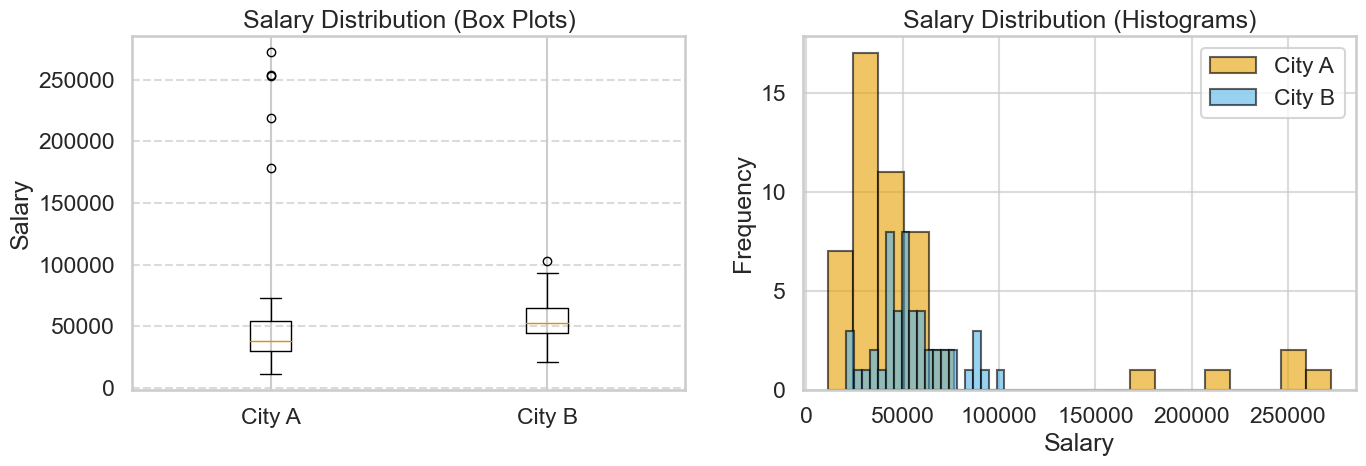

In [39]:
# TODO: Create visualizations
# Hint: Use axes[0].boxplot([data1, data2], tick_labels=[...]) for box plots
#       Use axes[1].hist(data, bins=20, alpha=0.6, label=..., color=...) for histograms
#       Create 2 subplots side by side

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots
# Assumes city_a_salary and city_b_salary from cell 4.1
# TODO: Use axes[0].boxplot() with list [city_a, city_b]
# Set tick_labels=['City A', 'City B']
axes[0].boxplot([city_a_salary, city_b_salary], labels=['City A', 'City B'])

# Set ylabel, title, and grid
axes[0].set_ylabel('Salary')
axes[0].set_title('Salary Distribution (Box Plots)')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.7)


# Histograms
# TODO: Create histogram for city_a with color='#E69F00', label='City A'
axes[1].hist(city_a_salary, bins=20, alpha=0.6, color='#E69F00', label='City A', edgecolor='black')

# TODO: Create histogram for city_b with color='#56B4E9', label='City B'
axes[1].hist(city_b_salary, bins=20, alpha=0.6, color='#56B4E9', label='City B', edgecolor='black')

# Use bins=20, alpha=0.6, edgecolor='black'
# Set xlabel, ylabel, title, legend, and grid
axes[1].set_xlabel('Salary')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Salary Distribution (Histograms)')
axes[1].legend()
axes[1].grid(True, alpha=0.7)


plt.tight_layout()
plt.show()

### Task 4.3: Compare Tests
- Perform t-test (parametric)
- Perform Mann-Whitney U test (nonparametric)
- Compare results and discuss robustness

In [42]:
# TODO: Compare parametric vs nonparametric tests
# Hint: Use stats.ttest_ind() for parametric t-test
#       Use stats.mannwhitneyu() for nonparametric Mann-Whitney U test
#       Compare how outliers affect each test

# TODO: Perform t-test (parametric - sensitive to outliers)
# Assumes city_a_salary, city_b_salary from 4.1
t_stat, t_pvalue = stats.ttest_ind(city_a_salary, city_b_salary, equal_var=False)

# TODO: Perform Mann-Whitney U test (nonparametric - robust to outliers)
u_stat, u_pvalue = stats.mannwhitneyu(city_a_salary, city_b_salary, alternative='two-sided')

# TODO: Print comparison and discuss robustness
print("\n***** Test Comparison ******\n")
print(f"Parametric (Welch's t-test):")
print(f"  t-Statistic: {t_stat:.4f}, p-Value: {t_pvalue:.4f}")
      
print(f"\nNonparametric (Mann-Whitney U):")
print(f"  U-Statistic: {u_stat:.4f}, p-Value: {u_pvalue:.4f}")
      
print("\nDiscussion on Robustness:")
print("  - The t-test compares means, which are highly sensitive to the outliers in City A's data.")
print("  - The Mann-Whitney U test compares medians (or more accurately, ranks) and is robust to outliers.")
print(f"  - Notice the t-test p-value ({t_pvalue:.4f}) might be inflated due to outliers, while the U-test p-value ({u_pvalue:.4f}) gives a more reliable comparison of the central tendency for this skewed data.")


***** Test Comparison ******

Parametric (Welch's t-test):
  t-Statistic: 0.3021, p-Value: 0.7637

Nonparametric (Mann-Whitney U):
  U-Statistic: 766.0000, p-Value: 0.0009

Discussion on Robustness:
  - The t-test compares means, which are highly sensitive to the outliers in City A's data.
  - The Mann-Whitney U test compares medians (or more accurately, ranks) and is robust to outliers.
  - Notice the t-test p-value (0.7637) might be inflated due to outliers, while the U-test p-value (0.0009) gives a more reliable comparison of the central tendency for this skewed data.


## Final Summary

### Task 5: Reflect on All Scenarios
- Summarize key findings from each scenario
- List 5 key takeaways about hypothesis testing

In [50]:
# TODO: Print final summary and key takeaways
# Hint: Summarize all 4 scenarios and list important lessons learned

print("\\n" + "="*70)
print("PRACTICAL LAB COMPLETE")
print("="*70)

# TODO: Summarize findings from each scenario
print("\n--- Summary of Findings ---")
print("\nScenario 1: Drug Trial Analysis (Welch's t-Test)")
print("  - Finding: Rejected H_0. Drug A leads to a significantly shorter recovery time than Drug B.")
print("  - Action: Checked normality and variance assumptions, performed a t-test for independent means, and calculated effect size (Cohen's d) and a 95% CI.")
      
print("\nScenario 2: A/B Test Analysis (Two-Proportion z-Test)")
print("  - Finding: Rejected H_0. Variant B has a significantly higher conversion rate than Variant A.")
print("  - Action: Performed a z-test for two proportions, calculated absolute/relative lift, and estimated the positive business impact (annual revenue).")
      
print("\nScenario 3: Survey Analysis (Chi-Squared Test)")
print("  - Finding: Rejected H_0. There is a significant association between age group and product preference.")
print("  - Action: Visualized the contingency table with heatmaps and used a Chi-squared test for independence to confirm the relationship.")
      
print("\nScenario 4: Non-Normal Data (Parametric vs. Nonparametric)")
print("  - Finding: The parametric t-test (sensitive to outliers) and nonparametric Mann-Whitney U test (robust to outliers) can yield different results.")
print("  - Action: Showed that for skewed data with outliers, the Mann-Whitney U test provides a more robust comparison of central tendency.")

# TODO: List 5 key takeaways about hypothesis testing
print("\n--- 5 Key Takeaways about Hypothesis Testing ---")

print("\n  1. CHECK ASSUMPTIONS: Always visualize data (histograms, box plots) and test assumptions (e.g., normality, equal variance) to select the correct test.")
print("  2. PARAMETRIC vs. NONPARAMETRIC: Use parametric tests (t-test) for normal data; use nonparametric tests (Mann-Whitney U) for skewed data, outliers, or small samples.")
print("  3. BEYOND THE p-VALUE: A small p-value indicates significance, but effect size (Cohen's d, relative lift) and Confidence Intervals (CIs) reveal the magnitude and practical importance* of the finding.")
print("  4. CHOOSE THE RIGHT TEST: The test must match the data type (continuous, proportional, categorical) and the hypothesis (comparing means, testing association, etc.).")
print("  5. FORMULATE CLEARLY: Define the Null (H_0) and Alternative (H_1) hypotheses and the significance level (α) 'before' testing to ensure a valid, unbiased conclusion.")

print("="*70)

\n======================================================================
PRACTICAL LAB COMPLETE

--- Summary of Findings ---

Scenario 1: Drug Trial Analysis (Welch's t-Test)
  - Finding: Rejected H_0. Drug A leads to a significantly shorter recovery time than Drug B.
  - Action: Checked normality and variance assumptions, performed a t-test for independent means, and calculated effect size (Cohen's d) and a 95% CI.

Scenario 2: A/B Test Analysis (Two-Proportion z-Test)
  - Finding: Rejected H_0. Variant B has a significantly higher conversion rate than Variant A.
  - Action: Performed a z-test for two proportions, calculated absolute/relative lift, and estimated the positive business impact (annual revenue).

Scenario 3: Survey Analysis (Chi-Squared Test)
  - Finding: Rejected H_0. There is a significant association between age group and product preference.
  - Action: Visualized the contingency table with heatmaps and used a Chi-squared test for independence to confirm the relationsh